# Gene Expression copy number correction

June 11, 2024

## Goal:
Apply copy number correction to gene expression data

**Procedure:**
1. Load replication timing
2. Load gene expression data for all genes (may take a while, start with a smaller set)
4. Copy number correction
5. Store corrected data for deconvolution


In [230]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [300]:
from src.figure_configs import save_figure_for_paper
from src.CopyNumberCorrection import CopyNumberCorrector

from src.timer import Timer

save_dir = 'output/copy_correction/gene_expression'

correctors = []

timer = Timer()
for config_type in ['shared', 'distinct', 'delta']:
    for replicate in [1, 2]:
        
        timer.print_time(f"Running {config_type}, replicate {replicate}")
        corrector = CopyNumberCorrector(config_type=config_type, replicate=replicate)
        corrector.load_gene_expression_data()
        corrector.correct_for_copy_number()
        corrector.compute_ptrs()

        # Save PTR comparison
        fig = corrector.plot_ptrs()
        save_path = f"{save_dir}/ptrs_rep{corrector.replicate}_{corrector.config_type}.png"
        save_figure_for_paper(save_path)
        plt.close()

        # Save correction dataframes
        corrector.save_correction(save_dir)
        
        correctors.append(corrector)


Running shared, replicate 1 - 00:00:00.000
0/5578 - 00:00:00.000
1000/5578 - 00:00:00.261
2000/5578 - 00:00:00.516
3000/5578 - 00:00:00.773
4000/5578 - 00:00:01.030
5000/5578 - 00:00:01.287
Saved to output/copy_correction/gene_expression/normalized_corrected_expression_rep1_shared.csv
Saved to output/copy_correction/gene_expression/correction_scaling_expression_rep1_shared.csv
Saved to output/copy_correction/gene_expression/expression_ptr_comparison_rep1_shared.csv
Running shared, replicate 2 - 00:00:03.098
0/5578 - 00:00:00.000
1000/5578 - 00:00:00.257
2000/5578 - 00:00:00.512
3000/5578 - 00:00:00.772
4000/5578 - 00:00:01.043
5000/5578 - 00:00:01.311
Saved to output/copy_correction/gene_expression/normalized_corrected_expression_rep2_shared.csv
Saved to output/copy_correction/gene_expression/correction_scaling_expression_rep2_shared.csv
Saved to output/copy_correction/gene_expression/expression_ptr_comparison_rep2_shared.csv
Running distinct, replicate 1 - 00:00:06.107
0/5578 - 00:00:

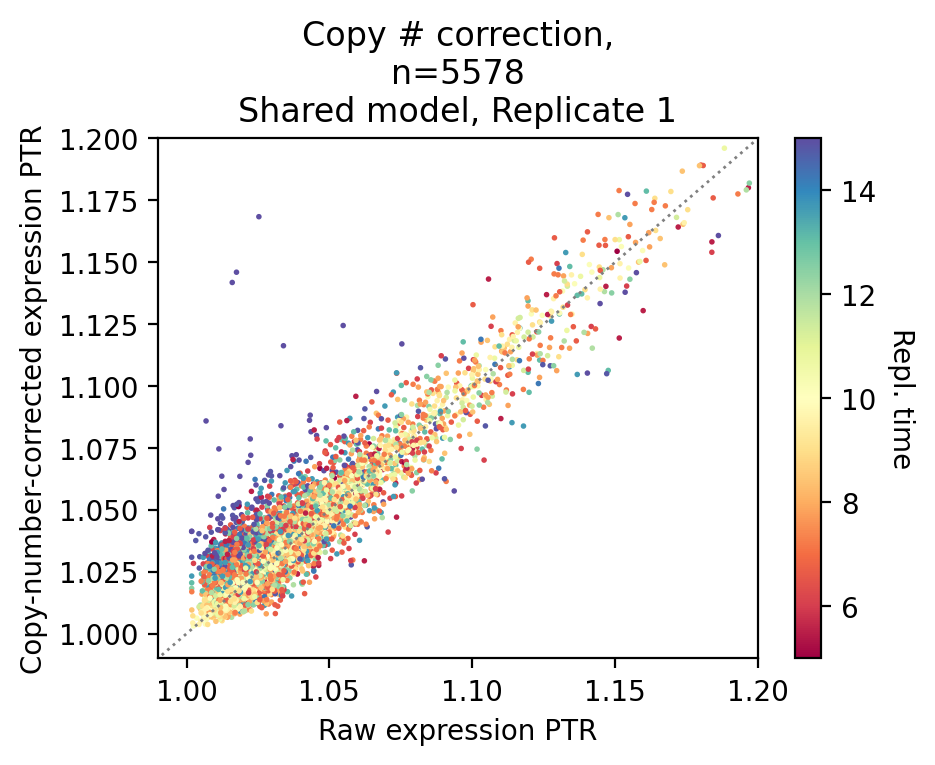

In [303]:
correctors[0].plot_ptrs()
plt.savefig('/Users/trung/Desktop/test.png')